In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
from google.colab import drive

# ==========================================
# 1. CẤU HÌNH HỆ THỐNG & DRIVE
# ==========================================
# Mount Google Drive
drive.mount('/content/drive')

# --- ĐƯỜNG DẪN ---
PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
Z_DATA_PATH = os.path.join(PROJECT_DIR, "inverse_results/z_dataset.npz")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "lgen_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
LOG_FILE_PATH = os.path.join(OUTPUT_DIR, "train_lgen_log.txt")

# --- HYPERPARAMETERS ---
EPOCHS = 5000         # Tổng số epoch
BATCH_SIZE = 128      # Batch size
LR = 0.0001           # Learning Rate
Z_DIM = 64
NOISE_DIM = 64
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ==========================================
# 2. HỆ THỐNG LOGGING (GHI FILE)
# ==========================================
def log_print(message):
    """In ra màn hình và ghi vào file log"""
    print(message)
    with open(LOG_FILE_PATH, "a", encoding="utf-8") as f:
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        f.write(f"[{timestamp}] {message}\n")

# ==========================================
# 3. CHUẨN BỊ DỮ LIỆU (AUTO-SCALE)
# ==========================================
def load_and_process_data():
    log_print("-" * 40)
    if not os.path.exists(Z_DATA_PATH):
        log_print(f"LỖI: Không tìm thấy file dữ liệu: {Z_DATA_PATH}")
        return None, None

    log_print(f"Đang đọc dữ liệu Z từ: {Z_DATA_PATH}")
    try:
        data = np.load(Z_DATA_PATH)
        z_vectors = data['z_vectors']
        log_print(f"Đã load {len(z_vectors)} vector.")
    except Exception as e:
        log_print(f"File dữ liệu bị lỗi: {e}")
        return None, None

    # Scale Z về [-1, 1]
    max_val = np.max(np.abs(z_vectors))
    scale_factor = max_val * 1.1

    log_print(f"Max Value gốc: {max_val:.4f}")
    log_print(f"Scale Factor: {scale_factor:.4f}")

    # Lưu scale factor
    scale_file = os.path.join(PROJECT_DIR, "z_scale_factor.npy")
    np.save(scale_file, np.array([scale_factor]))
    log_print(f"Đã lưu cấu hình scale: {scale_file}")

    z_normalized = z_vectors / scale_factor
    tensor_z = torch.FloatTensor(z_normalized)

    return tensor_z, scale_factor

# ==========================================
# 4. KIẾN TRÚC MẠNG
# ==========================================
class L_Generator(nn.Module):
    def __init__(self):
        super(L_Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(NOISE_DIM, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, Z_DIM),
            nn.Tanh()
        )
    def forward(self, x): return self.net(x)

class L_Discriminator(nn.Module):
    def __init__(self):
        super(L_Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
----------------------------------------
Đang đọc dữ liệu Z từ: /content/drive/MyDrive/BEGAN_PROJECT/inverse_results/z_dataset.npz
Đã load 202410 vector.
Max Value gốc: 31.4087
Scale Factor: 34.5496
Đã lưu cấu hình scale: /content/drive/MyDrive/BEGAN_PROJECT/z_scale_factor.npy
🚀 Đang đẩy toàn bộ dữ liệu lên GPU để tăng tốc...
⚡ Sử dụng Batch Size siêu lớn: 4096

🏎️ BẮT ĐẦU TRAINING TỐC ĐỘ CAO (5000 Epochs)
[Epoch 1/5000] Time: 0.4s | Speed: 2.4 ep/s | ETA: 0:34:06 | Loss D: 1.3882 | Loss G: 0.6854
[Epoch 25/5000] Time: 6.2s | Speed: 4.0 ep/s | ETA: 0:20:34 | Loss D: 1.3881 | Loss G: 0.6934
[Epoch 50/5000] Time: 12.2s | Speed: 4.1 ep/s | ETA: 0:20:08 | Loss D: 1.3876 | Loss G: 0.6937
[Epoch 75/5000] Time: 18.4s | Speed: 4.1 ep/s | ETA: 0:20:05 | Loss D: 1.3865 | Loss G: 0.6933
[Epoch 100/5000] Time: 24.5s | Speed: 4.1 ep/s | ETA: 0:19:58 | Loss D: 1.3869 | Los

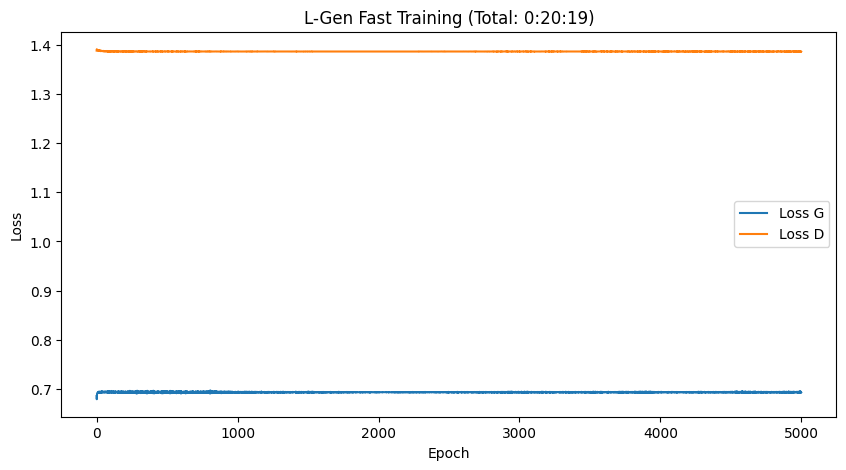

In [ ]:


# ==========================================
# 5. VÒNG LẶP HUẤN LUYỆN (CÓ TIME TRACKING)
# ==========================================
def format_time(seconds):
    return str(timedelta(seconds=int(seconds)))

# ... (Các phần import và model giữ nguyên) ...

# ==========================================
# PHIÊN BẢN TỐI ƯU HÓA TỐC ĐỘ (FULL GPU LOAD)
# ==========================================
def train_lgen_fast():
    # 1. Load Data
    z_data, scale_factor = load_and_process_data()
    if z_data is None: return

    # --- TỐI ƯU 1: Đẩy toàn bộ dữ liệu lên GPU ngay lập tức ---
    print("🚀 Đang đẩy toàn bộ dữ liệu lên GPU để tăng tốc...")
    z_data_gpu = z_data.to(DEVICE) # Nằm sẵn trên GPU
    total_samples = z_data_gpu.size(0)

    # --- TỐI ƯU 2: Tăng Batch Size cực đại ---
    # Với L-Gen, ta có thể train với batch size rất lớn
    BATCH_SIZE_FAST = 4096
    print(f"⚡ Sử dụng Batch Size siêu lớn: {BATCH_SIZE_FAST}")

    # Init Models
    l_gen = L_Generator().to(DEVICE)
    l_disc = L_Discriminator().to(DEVICE)

    opt_G = optim.Adam(l_gen.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_D = optim.Adam(l_disc.parameters(), lr=LR, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    log_print("\n" + "="*45)
    log_print(f"🏎️ BẮT ĐẦU TRAINING TỐC ĐỘ CAO ({EPOCHS} Epochs)")
    log_print("="*45)

    start_train_time = time.time()

    # Tạo các nhãn cố định trên GPU để đỡ phải tạo lại mỗi vòng lặp
    # (Lưu ý: Nếu batch cuối lẻ thì phải xử lý riêng, ở đây ta dùng drop_last=False thủ công)

    history_g = []
    history_d = []

    for epoch in range(1, EPOCHS + 1):
        # Xáo trộn dữ liệu thủ công trên GPU (nhanh hơn DataLoader)
        perm = torch.randperm(total_samples, device=DEVICE)
        z_data_shuffled = z_data_gpu[perm]

        loss_d_epoch = 0.0
        loss_g_epoch = 0.0
        num_batches = 0

        # Vòng lặp thủ công (Manual Batching)
        for i in range(0, total_samples, BATCH_SIZE_FAST):
            real_z = z_data_shuffled[i : i + BATCH_SIZE_FAST]
            curr_bs = real_z.size(0)

            # --- Train D ---
            opt_D.zero_grad()
            real_labels = torch.full((curr_bs, 1), 0.9, device=DEVICE) # Label smoothing 0.9
            fake_labels = torch.full((curr_bs, 1), 0.1, device=DEVICE) # Label smoothing 0.1

            pred_real = l_disc(real_z)
            loss_d_real = criterion(pred_real, real_labels)

            noise = torch.randn(curr_bs, NOISE_DIM, device=DEVICE)
            fake_z = l_gen(noise)
            pred_fake = l_disc(fake_z.detach())
            loss_d_fake = criterion(pred_fake, fake_labels)

            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            opt_D.step()

            # --- Train G ---
            opt_G.zero_grad()
            pred_fake_for_g = l_disc(fake_z)
            # G muốn D đoán là 1.0 (nhưng ta dùng label smoothing 0.9 cho nhất quán hoặc 1.0 tùy chọn)
            target_labels = torch.full((curr_bs, 1), 1.0, device=DEVICE)
            loss_g = criterion(pred_fake_for_g, target_labels)

            loss_g.backward()
            opt_G.step()

            loss_d_epoch += loss_d.item()
            loss_g_epoch += loss_g.item()
            num_batches += 1

        # Kết thúc Epoch
        avg_d_loss = loss_d_epoch / num_batches
        avg_g_loss = loss_g_epoch / num_batches
        history_d.append(avg_d_loss)
        history_g.append(avg_g_loss)

        # Log mỗi 100 epoch
        if epoch % 25 == 0 or epoch == 1:
            elapsed = time.time() - start_train_time
            # Tính ETA chuẩn xác hơn
            speed = epoch / elapsed # epochs per second
            remaining = EPOCHS - epoch
            eta = remaining / speed

            log_print(f"[Epoch {epoch}/{EPOCHS}] Time: {elapsed:.1f}s | Speed: {speed:.1f} ep/s | ETA: {format_time(eta)} | Loss D: {avg_d_loss:.4f} | Loss G: {avg_g_loss:.4f}")

        # Checkpoint (Mỗi 1000 epoch)
        if epoch % 100 == 0:
            torch.save(l_gen.state_dict(), os.path.join(OUTPUT_DIR, f"l_generator_epoch_{epoch}.pth"))

    # Kết thúc
    total_time = time.time() - start_train_time
    log_print("="*45)
    log_print(f"✅ HOÀN THÀNH SIÊU TỐC! Tổng thời gian: {format_time(total_time)}")

    final_path = os.path.join(PROJECT_DIR, "l_generator_final.pth")
    torch.save(l_gen.state_dict(), final_path)

    # Vẽ biểu đồ (Giữ nguyên)
    plt.figure(figsize=(10,5))
    plt.plot(history_g, label='Loss G')
    plt.plot(history_d, label='Loss D')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f"L-Gen Fast Training (Total: {format_time(total_time)})")
    plt.savefig(os.path.join(OUTPUT_DIR, "loss_chart_fast.png"))
    plt.show()

if __name__ == "__main__":
    train_lgen_fast() # Gọi hàm mới

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- ĐANG KIỂM TRA KẾT QUẢ ---
✅ Scale Factor: 34.5496
✅ Đã load L-Gen.
✅ Đã load BEGAN Decoder.


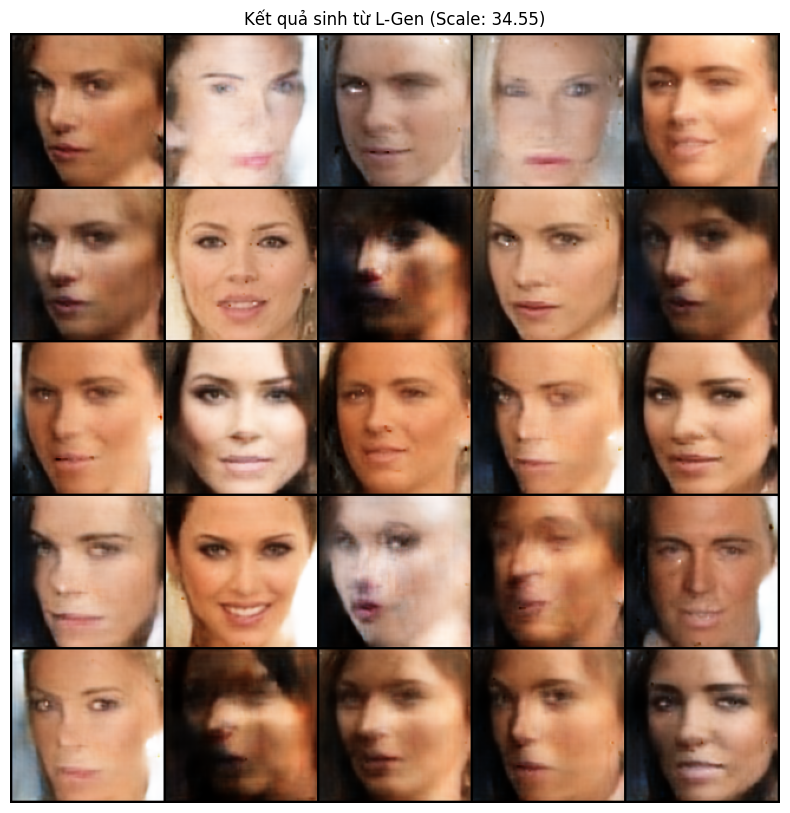

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import torchvision.utils as vutils
from google.colab import drive

# ==========================================
# 1. CẤU HÌNH & LOAD FILE
# ==========================================
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- ĐƯỜNG DẪN CÁC FILE CẦN THIẾT ---
# 1. Model L-Gen vừa train xong
L_GEN_PATH = os.path.join(PROJECT_DIR, "l_generator_final.pth")

# 2. Model BEGAN Decoder (Lấy cái xịn nhất ở Bước 2/3)
# Hãy sửa tên file này nếu bạn dùng tên khác (ví dụ: generator_epoch_128.pth)
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")

# 3. File Scale Factor (Chìa khóa giải mã)
SCALE_FILE = os.path.join(PROJECT_DIR, "z_scale_factor.npy")

# ==========================================
# 2. ĐỊNH NGHĨA LẠI MODEL (ĐỂ LOAD WEIGHT)
# ==========================================
Z_DIM = 64
NOISE_DIM = 64

class L_Generator(nn.Module):
    def __init__(self):
        super(L_Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(NOISE_DIM, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, Z_DIM), nn.Tanh()
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

# ==========================================
# 3. HÀM KIỂM TRA
# ==========================================
def test_generation(num_images=25):
    print("--- ĐANG KIỂM TRA KẾT QUẢ ---")

    # 1. Load Scale Factor
    if not os.path.exists(SCALE_FILE):
        print(f"❌ Lỗi: Không tìm thấy file {SCALE_FILE}")
        return
    scale_factor = float(np.load(SCALE_FILE)[0])
    print(f"✅ Scale Factor: {scale_factor:.4f}")

    # 2. Load L-Gen
    if not os.path.exists(L_GEN_PATH):
        print(f"❌ Lỗi: Không tìm thấy L-Gen tại {L_GEN_PATH}")
        return
    l_gen = L_Generator().to(DEVICE)
    l_gen.load_state_dict(torch.load(L_GEN_PATH, map_location=DEVICE))
    l_gen.eval()
    print("✅ Đã load L-Gen.")

    # 3. Load Decoder (BEGAN)
    decoder = Decoder().to(DEVICE)
    try:
        # Xử lý các kiểu lưu file khác nhau (chỉ weight hoặc cả checkpoint)
        checkpoint = torch.load(DECODER_PATH, map_location=DEVICE)
        if isinstance(checkpoint, dict) and 'generator_state_dict' in checkpoint:
            decoder.load_state_dict(checkpoint['generator_state_dict'])
        else:
            decoder.load_state_dict(checkpoint)
        decoder.eval()
        print("✅ Đã load BEGAN Decoder.")
    except Exception as e:
        print(f"❌ Lỗi load Decoder: {e}")
        print("Mẹo: Kiểm tra lại đường dẫn DECODER_PATH xem đúng file epoch 128 chưa.")
        return

    # 4. SINH ẢNH
    with torch.no_grad():
        # A. Tạo nhiễu
        noise = torch.randn(num_images, NOISE_DIM).to(DEVICE)

        # B. L-Gen sinh ra Z (khoảng -1 đến 1)
        z_fake = l_gen(noise)

        # C. Scale Z lên (QUAN TRỌNG NHẤT)
        z_scaled = z_fake * scale_factor

        # D. BEGAN sinh ảnh từ Z scaled
        imgs = decoder(z_scaled)

        # E. Hiển thị
        imgs = (imgs + 1) / 2.0 # Denormalize về 0-1
        grid = vutils.make_grid(imgs, nrow=5, padding=2, normalize=False)

        plt.figure(figsize=(10, 10))
        plt.axis("off")
        plt.title(f"Kết quả sinh từ L-Gen (Scale: {scale_factor:.2f})")
        plt.imshow(grid.cpu().permute(1, 2, 0))
        plt.show()

if __name__ == "__main__":
    test_generation()

🔬 ĐANG TÁI TẠO KẾT QUẢ VỚI FACE ALIGNMENT (FAN)...

📸 Kết quả 1: Biến hình (Interpolation)
⏳ Đang quét landmark cho 10 ảnh...


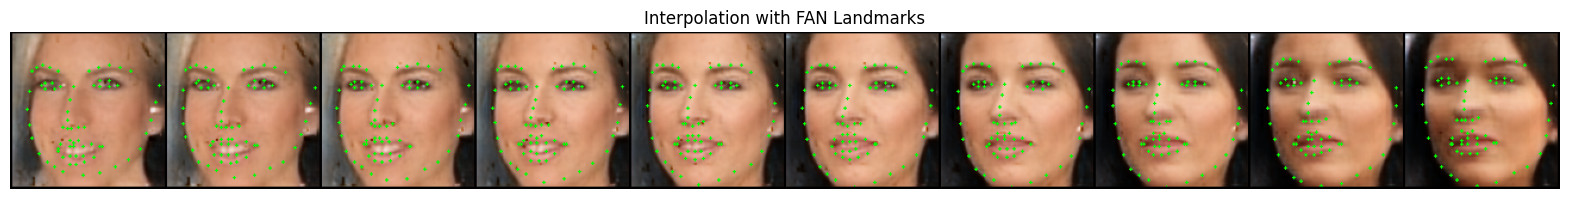


📸 Kết quả 2: Ảnh ngẫu nhiên (Random)
⏳ Đang quét landmark cho 16 ảnh...


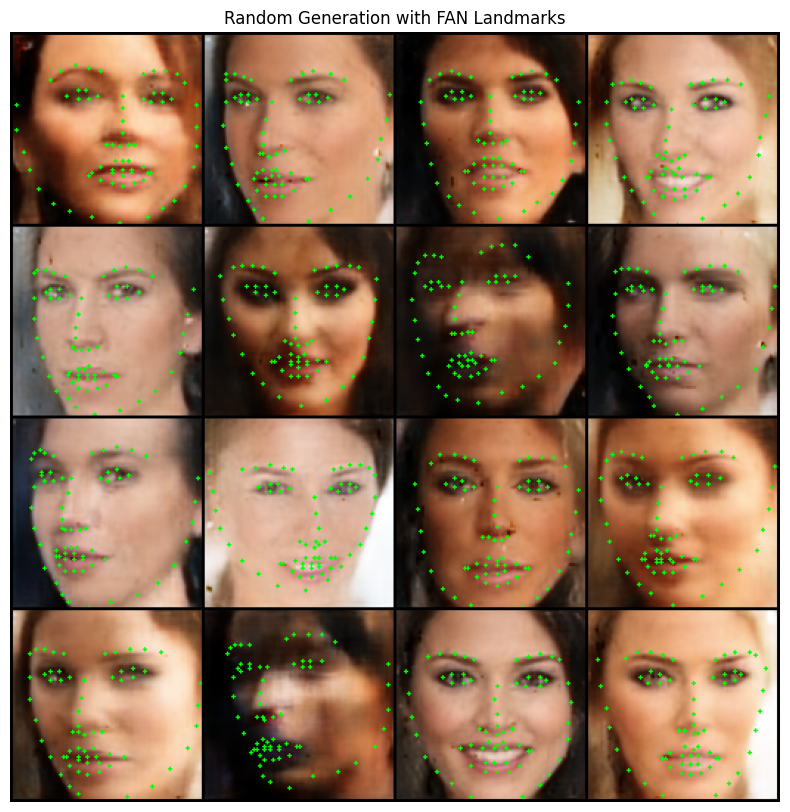

In [9]:
# 1. Cài đặt thư viện (Chạy 1 lần)
!pip install face-alignment

import face_alignment
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import os
from google.colab import drive

# --- CẤU HÌNH ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
LGEN_PATH = os.path.join(PROJECT_DIR, "l_generator_final.pth")
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")
SCALE_FILE = os.path.join(PROJECT_DIR, "z_scale_factor.npy")

# --- INIT MODELS (Giữ nguyên class cũ) ---
Z_DIM = 64
NOISE_DIM = 64

class L_Generator(nn.Module):
    def __init__(self):
        super(L_Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(NOISE_DIM, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, Z_DIM), nn.Tanh()
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

# --- HÀM VẼ LANDMARK MỚI (DÙNG FACE_ALIGNMENT) ---
def apply_landmarks_fan(images_tensor):
    """
    Dùng Face Alignment Network để bắt điểm
    """
    # Khởi tạo Face Alignment (chạy trên GPU cho nhanh)
    fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, device=DEVICE, flip_input=False)

    output_list = []

    # Chuyển tensor sang numpy ảnh (H, W, 3) chuẩn RGB
    images_np = images_tensor.cpu().permute(0, 2, 3, 1).detach().numpy()
    # Denormalize: [-1, 1] -> [0, 255]
    images_np = ((images_np + 1) / 2.0 * 255).astype(np.uint8)

    print(f"⏳ Đang quét landmark cho {len(images_np)} ảnh...")

    for i in range(len(images_np)):
        img = images_np[i].copy()

        # Fan nhận đầu vào là ảnh RGB numpy array
        try:
            # Dự đoán landmark
            preds = fa.get_landmarks(img)

            if preds:
                # preds là list các khuôn mặt, ta lấy mặt đầu tiên [0]
                points = preds[0]

                # Vẽ điểm
                for p in points:
                    x, y = int(p[0]), int(p[1])
                    # Vẽ chấm xanh lá cây (Green)
                    cv2.circle(img, (x, y), 1, (0, 255, 0), -1)
            else:
                # Nếu không tìm thấy mặt thì vẽ viền đỏ báo hiệu
                cv2.rectangle(img, (0,0), (127,127), (255,0,0), 2)

        except Exception as e:
            print(f"Lỗi ảnh {i}: {e}")

        output_list.append(torch.from_numpy(img).permute(2, 0, 1)) # Back to Tensor

    return torch.stack(output_list).float() / 255.0

# --- HÀM MAIN ---
def verify_with_fan():
    print("🔬 ĐANG TÁI TẠO KẾT QUẢ VỚI FACE ALIGNMENT (FAN)...")

    # Load Scale & Models
    if not os.path.exists(SCALE_FILE): return print("❌ Thiếu Scale File")
    scale_factor = float(np.load(SCALE_FILE)[0])

    l_gen = L_Generator().to(DEVICE)
    l_gen.load_state_dict(torch.load(LGEN_PATH, map_location=DEVICE))

    decoder = Decoder().to(DEVICE)
    checkpoint = torch.load(DECODER_PATH, map_location=DEVICE)
    if isinstance(checkpoint, dict) and 'generator_state_dict' in checkpoint:
        decoder.load_state_dict(checkpoint['generator_state_dict'])
    else:
        decoder.load_state_dict(checkpoint)

    l_gen.eval()
    decoder.eval()

    # 1. INTERPOLATION
    print("\n📸 Kết quả 1: Biến hình (Interpolation)")
    noise_A = torch.randn(1, NOISE_DIM).to(DEVICE)
    noise_B = torch.randn(1, NOISE_DIM).to(DEVICE)
    steps = 10
    alphas = np.linspace(0, 1, steps)

    img_list = []
    with torch.no_grad():
        for alpha in alphas:
            z = l_gen(noise_A * (1 - alpha) + noise_B * alpha) * scale_factor
            img_list.append(decoder(z))

    batch_imgs = torch.cat(img_list, dim=0)
    labeled_imgs = apply_landmarks_fan(batch_imgs)

    plt.figure(figsize=(20, 5))
    plt.axis("off")
    plt.title("Interpolation with FAN Landmarks")
    plt.imshow(vutils.make_grid(labeled_imgs, nrow=steps, padding=2).permute(1, 2, 0))
    plt.show()

    # 2. RANDOM GENERATION
    print("\n📸 Kết quả 2: Ảnh ngẫu nhiên (Random)")
    with torch.no_grad():
        noise = torch.randn(16, NOISE_DIM).to(DEVICE)
        z = l_gen(noise) * scale_factor
        batch_imgs = decoder(z)

    labeled_imgs = apply_landmarks_fan(batch_imgs)

    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.title("Random Generation with FAN Landmarks")
    plt.imshow(vutils.make_grid(labeled_imgs, nrow=4, padding=2).permute(1, 2, 0))
    plt.show()

if __name__ == "__main__":
    verify_with_fan()